# Equations of State

## Overview

The `polykin.thermo.eos` module provides equations of state (EOS) for gas and liquid mixtures.

|                     | Gas/Vapor | Liquid | VLE |
|---------------------|:---------:|:------:|-----|
| `IdealGas`          |     ✓     |    —   |  —  |
| `Virial`            |     ✓     |    —   |  —  |
| `RedlichKwong`      |     ✓     |    ✓   |  ✓  |
| `SoaveRedlichKwong` |     ✓     |    ✓   |  ✓  |
| `PengRobinson`      |     ✓     |    ✓   |  ✓  |

For dilute gases and moderate pressures, a virial EOS is often sufficient. For high-pressure fluids and vapor-liquid equilibrium calculations, cubic equations of state offer a practical compromise between model fidelity and computational cost.

## Air PVT up to Moderate Pressures

Let us estimate the molar volume and compressibility factor of air as a function of temperature and pressure using the virial EOS. Here, air is represented as a binary $\mathrm{N_2/O_2}$ mixture, which is adequate for this simple PVT illustration. As a rule of thumb, the virial model is most reliable when the gas remains well away from the dense-fluid regime, for example when $v/v_c > 2$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from polykin.thermo.eos import Virial

In [3]:
# Critical constants for N2, O2
Tc = [126.2, 154.6]
Pc = [33.9e5, 50.4e5]
Zc = [0.290, 0.288]
w = [0.039, 0.025]

eos = Virial(Tc, Pc, Zc, w, name="N2-O2")

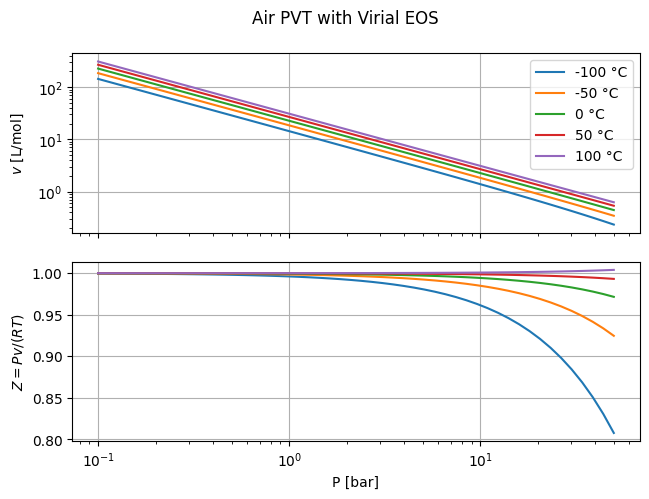

In [4]:
fig, ax = plt.subplots(2, 1, sharex=True)
fig.suptitle("Air PVT with Virial EOS")
fig.tight_layout()
fig.align_ylabels()

T = np.linspace(-100.0, 100.0, 5)  # °C
P = np.geomspace(0.1, 50.0, 50)    # bar
v = np.empty_like(P)
Z = np.empty_like(P)

# Air molar composition
y_air = np.array([0.79, 0.21])

for Ti in T:
    for j, Pj in enumerate(P):
        v[j] = eos.v(Ti + 273.15, Pj * 1e5, y_air)
        Z[j] = eos.Z(Ti + 273.15, Pj * 1e5, y_air)
    ax[0].plot(P, v * 1e3, label=f"{Ti:.0f} °C")
    ax[1].plot(P, Z, label=f"{Ti:.0f} °C")

ax[0].set_ylabel(r"$v$" + " [L/mol]")
ax[0].legend(loc="best")
ax[0].set_yscale("log")
ax[0].grid(True)

ax[1].set_ylabel(r"$Z = Pv/(RT)$")
ax[1].grid(True)

ax[-1].set_xlabel("P [bar]")
ax[-1].set_xscale("log");

## Ethylene PVT

Let us now examine the pressure dependence of the compressibility factor of ethylene using the Peng-Robinson EOS. Unlike the virial model, this cubic EOS remains useful over a much wider pressure range and can represent both vapor-like and dense-fluid states with the same pure-component parameters. In the calculation below, we retain the vapor root of the EOS to follow the gas-phase behavior.

In [5]:
from polykin.thermo.eos import PengRobinson

In [6]:
eos = PengRobinson(Tc=282.4, Pc=50.4e5, w=0.089, name="Ethylene")

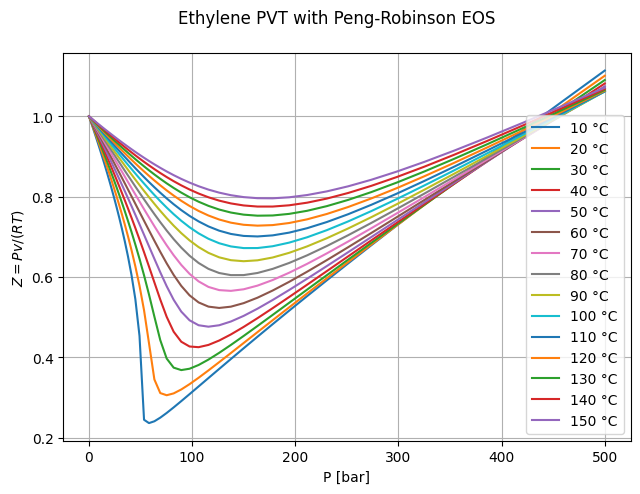

In [7]:
fig, ax = plt.subplots()
fig.suptitle("Ethylene PVT with Peng-Robinson EOS")
fig.tight_layout()

T = np.linspace(10.0, 150.0, 15)   # °C
P = np.geomspace(0.1, 500.0, 100)  # bar
Z = np.empty_like(P)

for Ti in T:
    for j, Pj in enumerate(P):
        Z[j] = eos.Z(Ti + 273.15, Pj*1e5, np.array([1.0]))[-1]  # get the vapor solution
    ax.plot(P, Z, label=f"{Ti:.0f} °C")

ax.set_xlabel("P [bar]")
ax.set_ylabel(r"$Z = Pv/(RT)$")
ax.grid(True)
ax.legend(loc='best');

## Pure-Component Vapor Pressure

As a first phase-equilibrium application, let us estimate the vapor pressure of styrene with the RK, SRK, and PR equations of state and compare the results with an Antoine correlation fitted to experimental data. In general, RK is the least accurate of the three for vapor-pressure work, whereas SRK and PR usually provide a similar and noticeably better description.

In [8]:
from polykin.properties import Antoine
from polykin.thermo.eos import RedlichKwong, SoaveRedlichKwong

In [9]:
# Critical constants for Styrene
Tc = 647.0
Pc = 39.9e5
w = 0.257
name = "Styrene"

RK_eos = RedlichKwong(Tc, Pc, name=name)
SRK_eos = SoaveRedlichKwong(Tc, Pc, w, name=name)
PR_eos = PengRobinson(Tc, Pc, w, name=name)

In [10]:
# Experimental vapor pressure correlation
Psat_exp = Antoine(
    A=4.21948,
    B=1525.059,
    C=-56.379,
    Tmin=303.07,
    Tmax=417.92,
    unit="bar",
    name="Styrene",
)

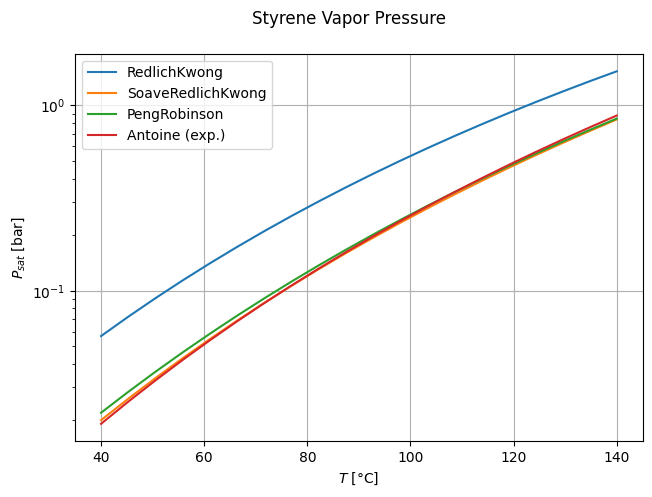

In [11]:
fig, ax = plt.subplots()
fig.suptitle("Styrene Vapor Pressure")
fig.tight_layout()

T = np.linspace(40.0, 140.0, 20)  # °C
Psat = np.empty_like(T)

for eos in [RK_eos, SRK_eos, PR_eos]:
    for i, Ti in enumerate(T):
        Psat[i] = eos.Psat(Ti + 273.15)
    ax.plot(T, Psat / 1e5, label=f"{eos.__class__.__name__}")

ax.plot(T, Psat_exp(T, "C"), label="Antoine (exp.)")

ax.set_xlabel(r"$T$" + " [°C]")
ax.set_ylabel(r"$P_{sat}$" + " [bar]")
ax.set_yscale("log")
ax.legend(loc="best")
ax.grid(True)

## Vapor Liquid Equilibrium

Let us finally compute a pressure-temperature envelope for the ethane(1)/heptane(2) system with the SRK EOS. For a fixed overall composition, the bubble and dew curves delimit the two-phase region, so tracing both branches provides a compact view of the mixture's phase behavior.

In [12]:
from polykin.thermo.flash import flash2_PV

In [13]:
# Critical constants for ethane, heptane
Tc = [305.4, 540.3]
Pc = [48.8e5, 27.4e5]
w = [0.099, 0.349]

eos = SoaveRedlichKwong(Tc, Pc, w, name="Ethane-Heptane")

In [14]:
# Mixture molar fractions
z = np.array([0.90, 0.10])

To generate the envelope, we solve a sequence of flash problems at increasing pressure and use each converged state as the initial guess for the next one. This continuation strategy greatly improves robustness and allows the bubble and dew curves to be traced smoothly as the two branches move toward the critical region. Very close to the critical point, however, the properties of the two phases become nearly indistinguishable, making the numerical problem significantly more challenging.

In [15]:
# Initial guesses for first flash calculation
T0 = 250.0
y0 = np.array([1.0, 0.0])

P = 10e5
ΔP = 5e5

results_bubble = []

for _ in range(100):
    result = flash2_PV(
        F=1.0,
        z=z,
        P=P,
        beta=0.0,
        Kcalc=eos.K,
        y0=y0,
        T0=T0,
        maxiter=30,
        rtol_outer=1e-4,
    )
    if result.success:
        results_bubble.append(result)
        P += ΔP
        T0 = result.T
        y0 = result.y
    else:
        print(f"Flash calculation failed at P={P / 1e5:.2f} bar. Reducing step size.")
        ΔP /= 2
        P -= ΔP
        if ΔP < 0.1e5:
            break

Flash calculation failed at P=70.00 bar. Reducing step size.
Flash calculation failed at P=75.00 bar. Reducing step size.
Flash calculation failed at P=73.75 bar. Reducing step size.
Flash calculation failed at P=73.12 bar. Reducing step size.
Flash calculation failed at P=73.12 bar. Reducing step size.
Flash calculation failed at P=73.75 bar. Reducing step size.


We repeat the same procedure for the dew branch.

In [16]:
# Initial guesses for first flash calculation
T0 = 350
x0 = np.array([0.0, 1.0])

P = 10e5
ΔP = 5e5

results_dew = []

for _ in range(100):
    result = flash2_PV(
        F=1.0,
        z=z,
        P=P,
        beta=1.0,
        Kcalc=eos.K,
        x0=x0,
        T0=T0,
        maxiter=30,
        rtol_outer=1e-4,
    )
    if result.success:
        results_dew.append(result)
        P += ΔP
        T0 = result.T
        x0 = result.x
    else:
        print(f"Flash calculation failed at P={P / 1e5:.2f} bar. Reducing step size.")
        ΔP /= 2
        P -= ΔP
        if ΔP < 0.1e5:
            break

Flash calculation failed at P=85.00 bar. Reducing step size.
Flash calculation failed at P=85.00 bar. Reducing step size.
Flash calculation failed at P=83.75 bar. Reducing step size.
Flash calculation failed at P=83.75 bar. Reducing step size.
Flash calculation failed at P=83.44 bar. Reducing step size.
Flash calculation failed at P=83.75 bar. Reducing step size.


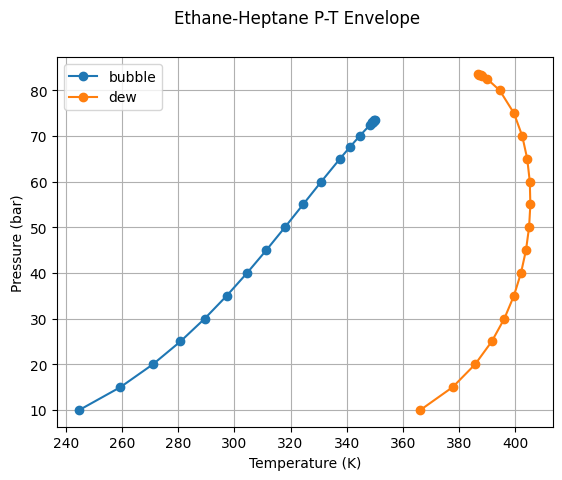

In [17]:
fig, ax = plt.subplots()
fig.suptitle("Ethane-Heptane P-T Envelope")

# Plot bubble curve
T = np.array([res.T for res in results_bubble])
P = np.array([res.P for res in results_bubble]) / 1e5
ax.plot(T, P, marker="o", label="bubble")

# Plot dew curve
T = np.array([res.T for res in results_dew])
P = np.array([res.P for res in results_dew]) / 1e5
ax.plot(T, P, marker="o", label="dew")

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Pressure (bar)")
ax.legend(loc="upper left")
ax.grid(True)